<a href="https://colab.research.google.com/github/Muhammad-Waleed-Source/Machine-Learning/blob/main/Day-56/LR-Assumptions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data.csv')

In [3]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


## Train test split

In [4]:
X = df.iloc[:,0:3].values
y = df.iloc[:,-1].values

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

## Training Model

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [10]:
y_pred = model.predict(X_test)
residual = y_test - y_pred

## 1. Linear Relationship

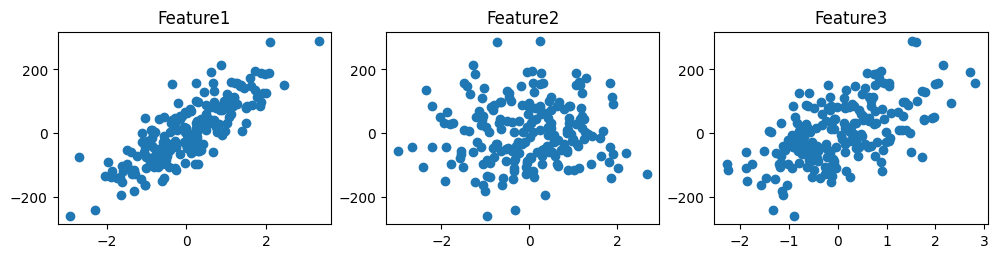

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature1")
ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature2")
ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature3")

plt.show()

## 2. Multicollinearity

Method 1

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [16]:
vif = []

for i in range(X_train.shape[1]):
  vif.append(variance_inflation_factor(X_train, i))

In [22]:
print(vif)

[np.float64(1.0103257033229724), np.float64(1.0098710800698711), np.float64(1.0139501973126546)]


In [21]:
pd.DataFrame({'vif': vif}, index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.010326,1.009871,1.01395


Method 2

<Axes: >

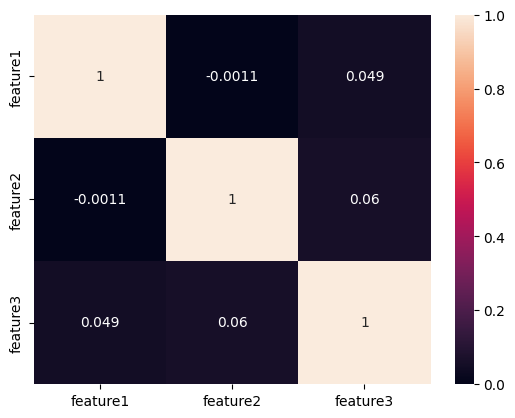

In [24]:
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)